# Comparación: Archivos CHIME raw vs CSVs procesados (AQUATIME)

Este notebook lee ambos tipos de archivos y compara su contenido:
- **Raw CHIME** (`chime_05_belgium`, `chime_05_meas_01`, `chime_10_belgium`, `chime_10_meas_01`)
- **CSVs procesados** (`AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv`, etc.)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajusta este path a tu carpeta
# ─────────────────────────────────────────────
# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")   # adjust as needed
DATA_RAW = DATA_DIR         # Ajusta si tu estructura es diferente (p.ej. DATA_DIR/"raw")



RAW_FILES = {
    "chime_05_belgium" : cfg.DATA_RAW / "CHIME" / "chime_05_belgium",
    "chime_05_meas_01" : cfg.DATA_RAW / "CHIME" / "chime_05_meas_01",
    "chime_10_belgium" : cfg.DATA_RAW / "CHIME"/ "chime_10_belgium" ,
    "chime_10_meas_01" : cfg.DATA_RAW / "CHIME" / "chime_10_meas_01",
}

CSV_FILES = {
    "5nm"  : cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv",
    "10nm" : cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv",
    "lstm" : cfg.DATA_RAW / "LSTM" / "AQUATIME_D2.1.0_RD-belgian-coast-lstm-convolved-v0.1.csv",
}

print("✓ Configuración cargada")
print(f"  Directorio: {DATA_DIR}")

✓ Configuración cargada
  Directorio: ..\data


---
## 1. Detección de formato — archivos raw CHIME

In [ ]:
def detect_and_read_raw(filepath):
    """
    Intenta leer un archivo raw CHIME probando varios formatos.
    Devuelve (formato_detectado, objeto_leído).
    """
    name = os.path.basename(filepath)

    # 1) NetCDF4 / HDF5
    try:
        import netCDF4 as nc
        ds = nc.Dataset(filepath)
        print(f"  [{name}] → NetCDF4")
        return "netcdf", ds
    except Exception:
        pass

    # 2) HDF5 puro
    try:
        import h5py
        ds = h5py.File(filepath, "r")
        print(f"  [{name}] → HDF5")
        return "hdf5", ds
    except Exception:
        pass

    # 3) CSV / texto con delimitador
    try:
        df = pd.read_csv(filepath, sep=None, engine="python", nrows=5)
        print(f"  [{name}] → CSV/texto")
        print(f"    Columnas detectadas: {df.columns.tolist()}")
        print(f"    Primeras filas:\n{df.head()}")
        print(f"    Tipos de datos:\n{df.dtypes}")
        print(f"    Estadísticas básicas:\n{df.describe(include='all')}")
        print (f"    Formato:\n{df.shape}")
        print(f"    tamano:\n{df.length}")
        df_full = pd.read_csv(filepath, sep=None, engine="python")
        print(f"    Total filas: {len(df_full)}") # spectro or lines
        return "csv", df_full
    except Exception:
        pass

    # 4) Binario numpy
    try:
        arr = np.fromfile(filepath, dtype=np.float32)
        print(f"  [{name}] → binario float32 ({arr.shape[0]} valores)")
        return "binary", arr
    except Exception:
        pass

    print(f"  [{name}] → formato desconocido")
    return "unknown", None


print("Detectando formato de archivos raw:")
raw_data = {}
for key, path in RAW_FILES.items():
    if os.path.exists(path):
        fmt, obj = detect_and_read_raw(path)
        raw_data[key] = {"fmt": fmt, "obj": obj, "path": path}
    else:
        print(f"  [{key}] → archivo NO encontrado en {path}")

Detectando formato de archivos raw:
  [chime_05_belgium] → CSV/texto
    Columnas detectadas: ['icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000', '440.000000', '445.000000', '450.000000', '455.000000', '460.000000', '465.000000', '470.000000', '475.000000', '480.000000', '485.000000', '490.000000', '495.000000', '500.000000', '505.000000', '510.000000', '515.000000', '520.000000', '525.000000', '530.000000', '535.000000', '540.000000', '545.000000', '550.000000', '555.000000', '560.000000', '565.000000', '570.000000', '575.000000', '580.000000', '585.000000', '590.000000', '595.000000', '600.000000', '605.000000', '610.000000', '615.000000', '620.000000', '625.000000', '630.000000', '635.000000', '640.000000', '645.000000', '650.000000', '655.000000', '660.000000', '665.000000', 

---
## 2. Inspección de archivos raw — estructura y metadatos

In [5]:
def inspect_raw(key, info):
    fmt, obj = info["fmt"], info["obj"]
    print(f"\n{'='*60}")
    print(f" {key}  [{fmt}]")
    print(f"{'='*60}")

    if fmt == "netcdf":
        print("  Dimensiones:", dict(obj.dimensions))
        print("  Variables:", list(obj.variables.keys()))
        for vname, var in obj.variables.items():
            print(f"    {vname:30s} shape={var.shape}  dtype={var.dtype}")

    elif fmt == "hdf5":
        def print_hdf5(name, obj_):
            if hasattr(obj_, "shape"):
                print(f"    {name:40s} shape={obj_.shape}  dtype={obj_.dtype}")
            else:
                print(f"    {name}/")
        obj.visititems(print_hdf5)

    elif fmt == "csv":
        print(f"  Filas: {len(obj)}   Columnas: {len(obj.columns)}")
        print("  Columnas:", list(obj.columns[:20]), "..." if len(obj.columns) > 20 else "")
        display(obj.head(3))

    elif fmt == "binary":
        print(f"  {obj.shape[0]} valores float32")
        print(f"  min={obj.min():.4f}  max={obj.max():.4f}  mean={obj.mean():.4f}")

for key, info in raw_data.items():
    inspect_raw(key, info)


 chime_05_belgium  [csv]
  Filas: 779   Columnas: 121
  Columnas: ['icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000', '440.000000'] ...


,icase,350.000000,355.000000,360.000000,365.000000,370.000000,375.000000,380.000000,385.000000,390.000000,...,900.000000,905.000000,910.000000,915.000000,920.000000,925.000000,930.000000,935.000000,940.000000,945.000000
0,0,0.042590,0.043189,0.044856,0.046275,0.047343,0.049339,0.051643,0.053817,0.056194,...,0.007098,0.006871,0.006614,0.006196,0.005677,0.005229,0.004994,0.004752,0.004441,0.004208
1,1,0.037378,0.037909,0.039379,0.040694,0.041680,0.043495,0.045572,0.047560,0.049744,...,0.006400,0.006233,0.005936,0.005604,0.005172,0.004766,0.004423,0.004307,0.003931,0.003811
2,2,0.025687,0.026093,0.027218,0.028273,0.029176,0.030719,0.032528,0.034379,0.036433,...,0.006378,0.006187,0.005995,0.005766,0.005435,0.005036,0.004816,0.004523,0.004238,0.004119



 chime_05_meas_01  [csv]
  Filas: 183   Columnas: 111
  Columnas: ['icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000', '440.000000'] ...


,icase,350.000000,355.000000,360.000000,365.000000,370.000000,375.000000,380.000000,385.000000,390.000000,...,850.000000,855.000000,860.000000,865.000000,870.000000,875.000000,880.000000,885.000000,890.000000,895.000000
0,0,0.002795,0.002739,0.002703,0.002630,0.002557,0.002523,0.002478,0.002445,0.002415,...,0.001521,0.001494,0.001512,0.001475,0.001419,0.001391,0.001379,0.001397,0.001284,0.001132
1,1,0.002694,0.002638,0.002565,0.002500,0.002432,0.002402,0.002362,0.002330,0.002285,...,0.001408,0.001368,0.001346,0.001337,0.001346,0.001351,0.001325,0.001301,0.001246,0.001199
2,2,0.002756,0.002666,0.002581,0.002511,0.002435,0.002417,0.002354,0.002328,0.002306,...,0.001236,0.001221,0.001231,0.001196,0.001173,0.001178,0.001163,0.001132,0.001033,0.000881



 chime_10_belgium  [csv]
  Filas: 779   Columnas: 61
  Columnas: ['icase', '350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000', '430.000000', '440.000000', '450.000000', '460.000000', '470.000000', '480.000000', '490.000000', '500.000000', '510.000000', '520.000000', '530.000000'] ...


,icase,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,430.000000,...,850.000000,860.000000,870.000000,880.000000,890.000000,900.000000,910.000000,920.000000,930.000000,940.000000
0,0,0.043332,0.045020,0.047565,0.051611,0.055994,0.059616,0.062693,0.066474,0.072081,...,0.011252,0.010227,0.009344,0.008459,0.007708,0.007107,0.006573,0.005697,0.004994,0.004532
1,1,0.038034,0.039541,0.041878,0.045551,0.049571,0.052972,0.055926,0.059486,0.064654,...,0.010135,0.009201,0.008395,0.007638,0.006954,0.006420,0.005923,0.005179,0.004480,0.004048
2,2,0.026188,0.027357,0.029331,0.032540,0.036328,0.039902,0.043313,0.047266,0.052493,...,0.009271,0.008561,0.007976,0.007388,0.006865,0.006385,0.005984,0.005418,0.004800,0.004336



 chime_10_meas_01  [csv]
  Filas: 183   Columnas: 56
  Columnas: ['icase', '350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000', '430.000000', '440.000000', '450.000000', '460.000000', '470.000000', '480.000000', '490.000000', '500.000000', '510.000000', '520.000000', '530.000000'] ...


,icase,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,430.000000,...,800.000000,810.000000,820.000000,830.000000,840.000000,850.000000,860.000000,870.000000,880.000000,890.000000
0,0,0.002767,0.002694,0.002567,0.002481,0.002427,0.002387,0.002352,0.002345,0.002351,...,0.001732,0.001746,0.001606,0.001585,0.001536,0.001520,0.001499,0.001426,0.001384,0.001277
1,1,0.002665,0.002566,0.002442,0.002364,0.002292,0.002217,0.002182,0.002177,0.002191,...,0.001556,0.001579,0.001514,0.001451,0.001416,0.001395,0.001350,0.001344,0.001325,0.001249
2,2,0.002712,0.002584,0.002450,0.002363,0.002312,0.002261,0.002245,0.002253,0.002255,...,0.001495,0.001524,0.001395,0.001356,0.001298,0.001242,0.001220,0.001179,0.001158,0.001022


---
## 3. Lectura de CSVs procesados (AQUATIME)

In [7]:
def read_aquatime_csv(filepath):
    """Lee un CSV AQUATIME con detección automática de separador."""
    # Acepta pathlib.Path o str
    p = Path(filepath)

    candidates = [p]
    if p.suffix.lower() != ".csv":
        candidates.append(p.with_suffix(".csv"))

    for path in candidates:
        if path.exists():
            df = pd.read_csv(path, sep=None, engine="python")
            return df, path
    return None, None


print("Leyendo CSVs procesados (AQUATIME):")
csv_data = {}
for key, path in CSV_FILES.items():
    df, found_path = read_aquatime_csv(path)
    if df is not None:
        csv_data[key] = df
        print(f"  [{key}] → {os.path.basename(found_path)}")
        print(f"           filas={len(df)}  columnas={len(df.columns)}")
    else:
        print(f"  [{key}] → archivo NO encontrado")

Leyendo CSVs procesados (AQUATIME):
  [5nm] → AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv
           filas=779  columnas=122
  [10nm] → AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv
           filas=779  columnas=62
  [lstm] → archivo NO encontrado


---
## 4. Inspección de CSVs — columnas y primeras filas

In [8]:
for key, df in csv_data.items():
    print(f"\n{'='*60}")
    print(f" CSV: {key}")
    print(f"{'='*60}")
    print(f"  Shape: {df.shape}")
    print(f"  Columnas ({len(df.columns)}): {list(df.columns[:10])}", "..." if len(df.columns) > 10 else "")
    print(f"  Tipos:\n{df.dtypes.value_counts().to_string()}")
    if "datetime" in df.columns or "date" in df.columns.str.lower().tolist():
        date_col = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        print(f"  Rango temporal: {df[date_col].min()} → {df[date_col].max()}")
    display(df.head(3))


 CSV: 5nm
  Shape: (779, 122)
  Columnas (122): ['date', 'icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000'] ...
  Tipos:
float64    120
str          1
int64        1
  Rango temporal: 1970-01-01 00:00:00 → 1970-01-01 00:00:00


,date,icase,350.000000,355.000000,360.000000,365.000000,370.000000,375.000000,380.000000,385.000000,...,900.000000,905.000000,910.000000,915.000000,920.000000,925.000000,930.000000,935.000000,940.000000,945.000000
0,1970-01-01,0,0.042590,0.043189,0.044856,0.046275,0.047343,0.049339,0.051643,0.053817,...,0.007098,0.006871,0.006614,0.006196,0.005677,0.005229,0.004994,0.004752,0.004441,0.004208
1,1970-01-01,1,0.037378,0.037909,0.039379,0.040694,0.041680,0.043495,0.045572,0.047560,...,0.006400,0.006233,0.005936,0.005604,0.005172,0.004766,0.004423,0.004307,0.003931,0.003811
2,1970-01-01,2,0.025687,0.026093,0.027218,0.028273,0.029176,0.030719,0.032528,0.034379,...,0.006378,0.006187,0.005995,0.005766,0.005435,0.005036,0.004816,0.004523,0.004238,0.004119



 CSV: 10nm
  Shape: (779, 62)
  Columnas (62): ['date', 'icase', '350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000'] ...
  Tipos:
float64    60
str         1
int64       1
  Rango temporal: 1970-01-01 00:00:00 → 1970-01-01 00:00:00


,date,icase,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,...,850.000000,860.000000,870.000000,880.000000,890.000000,900.000000,910.000000,920.000000,930.000000,940.000000
0,1970-01-01,0,0.043332,0.045020,0.047565,0.051611,0.055994,0.059616,0.062693,0.066474,...,0.011252,0.010227,0.009344,0.008459,0.007708,0.007107,0.006573,0.005697,0.004994,0.004532
1,1970-01-01,1,0.038034,0.039541,0.041878,0.045551,0.049571,0.052972,0.055926,0.059486,...,0.010135,0.009201,0.008395,0.007638,0.006954,0.006420,0.005923,0.005179,0.004480,0.004048
2,1970-01-01,2,0.026188,0.027357,0.029331,0.032540,0.036328,0.039902,0.043313,0.047266,...,0.009271,0.008561,0.007976,0.007388,0.006865,0.006385,0.005984,0.005418,0.004800,0.004336


---
## 5. Extracción de bandas espectrales de los archivos raw
> Ajusta esta celda según el formato detectado en la Sección 1

In [17]:
def extract_spectra_from_raw(key, info):
    """
    Extrae wavelengths y Rrs de un archivo raw.
    Adapta los nombres de variables a tu formato real.
    """
    fmt, obj = info["fmt"], info["obj"]

    if fmt == "netcdf":
        # --- NetCDF: ajusta los nombres de variable ---
        wl_candidates  = ["wavelength", "lambda", "wl", "bands", "centre_wavelength"]
        rrs_candidates = ["Rrs", "rrs", "reflectance", "Rw", "rw", "Rho_w"]

        wl = None
        for c in wl_candidates:
            if c in obj.variables:
                wl = np.array(obj.variables[c][:])
                print(f"  [{key}] wavelength var → '{c}'")
                break

        rrs = None
        for c in rrs_candidates:
            if c in obj.variables:
                rrs = np.array(obj.variables[c][:])
                print(f"  [{key}] Rrs var         → '{c}' shape={rrs.shape}")
                break

        return wl, rrs

    elif fmt == "hdf5":
        print(f"  [{key}] HDF5 keys: {list(obj.keys())}")
        return None, None

    elif fmt == "csv":
        # --- CSV raw: filtra columnas cuyo NOMBRE sea convertible a float ---
        # (evita incluir columnas como 'icase' que son numéricas en valores pero no son bandas)
        wl_cols = []
        wl_vals = []
        for c in obj.columns:
            try:
                v = float(c)
                wl_cols.append(c)
                wl_vals.append(v)
            except (ValueError, TypeError):
                pass
        if wl_cols:
            wl  = np.array(wl_vals)
            rrs = obj[wl_cols].values.astype(float)
            print(f"  [{key}] {len(wl)} bandas ({wl[0]:.1f}–{wl[-1]:.1f} nm)  |  {rrs.shape[0]} espectros")
            return wl, rrs
        return None, None

    elif fmt == "binary":
        print(f"  [{key}] binario crudo — necesitas conocer shape/wavelengths externos")
        return None, None

    return None, None


spectra_raw = {}
print("Extrayendo bandas de archivos raw:")
for key, info in raw_data.items():
    wl, rrs = extract_spectra_from_raw(key, info)
    spectra_raw[key] = {"wl": wl, "rrs": rrs}

Extrayendo bandas de archivos raw:
  [chime_05_belgium] 120 bandas (350.0–945.0 nm)  |  779 espectros
  [chime_05_meas_01] 110 bandas (350.0–895.0 nm)  |  183 espectros
  [chime_10_belgium] 60 bandas (350.0–940.0 nm)  |  779 espectros
  [chime_10_meas_01] 55 bandas (350.0–890.0 nm)  |  183 espectros


---
## 6. Extracción de bandas espectrales de los CSVs
> Detecta automáticamente columnas numéricas (longitudes de onda)

In [ ]:
def extract_spectra_from_csv(key, df):
    """
    Detecta columnas que corresponden a bandas espectrales.
    Asume que las columnas con nombre numérico (o con patrón 'Rrs_NNN') son longitudes de onda.
    """
    print(f"  [{key}] df.shape: {df.shape}  (filas x columnas)")
    # Patrón 1: columnas con nombre numérico directo (p.ej. '400', '405', ...)
    numeric_named = []
    for c in df.columns:
        try:
            float(c)
            numeric_named.append(c)
        except (ValueError, TypeError):
            pass

    # Patrón 2: columnas tipo 'Rrs_400', 'wl_400', 'band_400'
    import re
    prefixed = [c for c in df.columns if re.match(r"(Rrs|rrs|wl|band)_?(\d+\.?\d*)", c)]

    if numeric_named:
        wl  = np.array([float(c) for c in numeric_named])
        rrs = df[numeric_named].values
        print(f"  [{key}] {len(wl)} bandas ({wl[0]:.1f}–{wl[-1]:.1f} nm)  |  {rrs.shape[0]} espectros")
        return wl, rrs

    elif prefixed:
        nums = [re.search(r"(\d+\.?\d*)", c).group() for c in prefixed]
        wl  = np.array([float(n) for n in nums])
        rrs = df[prefixed].values
        print(f"  [{key}] {len(wl)} bandas ({wl[0]:.1f}–{wl[-1]:.1f} nm)  |  {rrs.shape[0]} espectros")
        return wl, rrs

    else:
        print(f"  [{key}] No se detectaron columnas espectrales. Columnas disponibles: {list(df.columns[:10])}")
        return None, None


spectra_csv = {}
print("Extrayendo bandas de CSVs:")
for key, df in csv_data.items():
    wl, rrs = extract_spectra_from_csv(key, df)
    spectra_csv[key] = {"wl": wl, "rrs": rrs}

Extrayendo bandas de CSVs:
  [5nm] 120 bandas (350.0–945.0 nm)  |  779 espectros
  [10nm] 60 bandas (350.0–940.0 nm)  |  779 espectros


---
## 7. Comparación de cobertura espectral

In [19]:
print("\nCobertura espectral — resumen\n")
print(f"{'Archivo':<30} {'Tipo':<8} {'N bandas':>8} {'λ min':>8} {'λ max':>8} {'Δλ':>6}")
print("-"*65)

all_spectra = [(k, "raw", v) for k, v in spectra_raw.items()] + \
              [(k, "csv", v) for k, v in spectra_csv.items()]

for name, kind, spec in all_spectra:
    wl = spec["wl"]
    if wl is not None and len(wl) > 1:
        delta = np.round(np.median(np.diff(wl)), 2)
        print(f"{name:<30} {kind:<8} {len(wl):>8} {wl[0]:>8.1f} {wl[-1]:>8.1f} {delta:>6.1f}")
    else:
        print(f"{name:<30} {kind:<8} {'—':>8}")


Cobertura espectral — resumen

Archivo                        Tipo     N bandas    λ min    λ max     Δλ
-----------------------------------------------------------------
chime_05_belgium               raw           120    350.0    945.0    5.0
chime_05_meas_01               raw           110    350.0    895.0    5.0
chime_10_belgium               raw            60    350.0    940.0   10.0
chime_10_meas_01               raw            55    350.0    890.0   10.0
5nm                            csv           120    350.0    945.0    5.0
10nm                           csv            60    350.0    940.0   10.0


---
## 8A. Comparación visual: espectros medios raw vs CSV

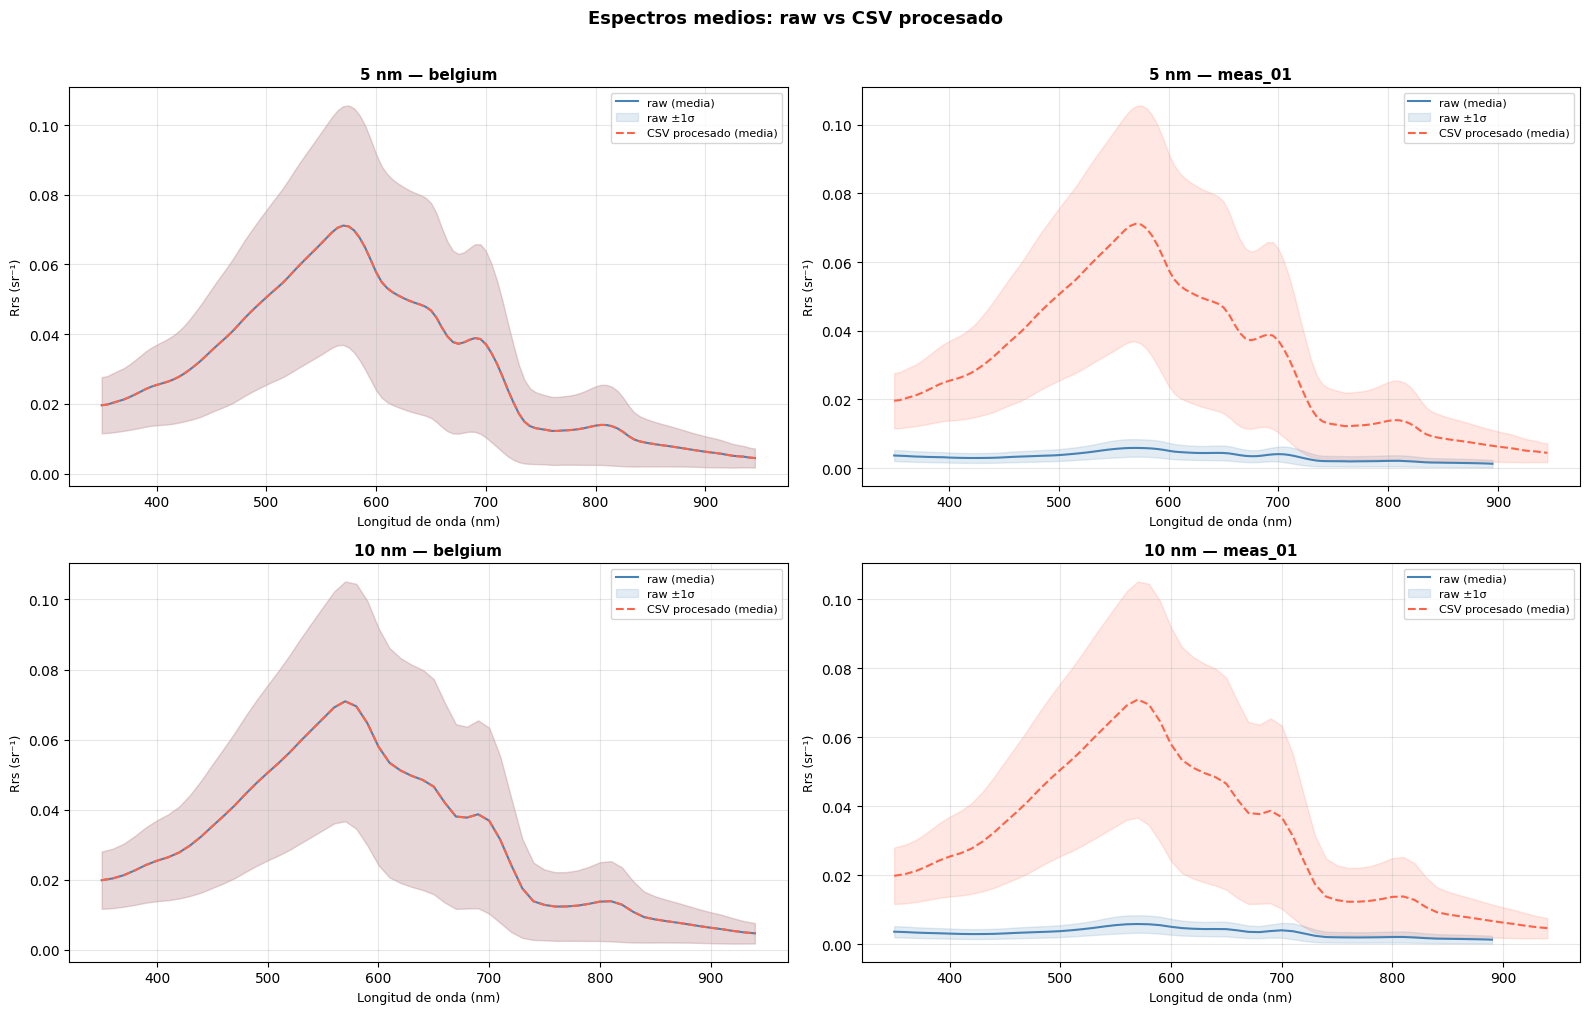

✓ Figura guardada como compare_spectra_raw_vs_csv.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

pairs = [
    ("chime_05_belgium", "5nm",  "5 nm — belgium"),
    ("chime_05_meas_01", "5nm",  "5 nm — meas_01"),
    ("chime_10_belgium", "10nm", "10 nm — belgium"),
    ("chime_10_meas_01", "10nm", "10 nm — meas_01"),
]

for ax, (raw_key, csv_key, title) in zip(axes, pairs):
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Raw
    raw_spec = spectra_raw.get(raw_key, {})
    if raw_spec.get("wl") is not None and raw_spec.get("rrs") is not None:
        rrs_r = raw_spec["rrs"]
        mean_r = np.nanmean(rrs_r, axis=0) if rrs_r.ndim > 1 else rrs_r
        ax.plot(raw_spec["wl"], mean_r, color="steelblue", lw=1.5, label="raw (media)")
        if rrs_r.ndim > 1:
            std_r = np.nanstd(rrs_r, axis=0)
            ax.fill_between(raw_spec["wl"], mean_r - std_r, mean_r + std_r,
                            alpha=0.15, color="steelblue", label="raw ±1σ")

    # CSV
    csv_spec = spectra_csv.get(csv_key, {})
    if csv_spec.get("wl") is not None and csv_spec.get("rrs") is not None:
        rrs_c = csv_spec["rrs"]
        mean_c = np.nanmean(rrs_c, axis=0) if rrs_c.ndim > 1 else rrs_c
        ax.plot(csv_spec["wl"], mean_c, color="tomato", lw=1.5, ls="--", label="CSV procesado (media)")
        if rrs_c.ndim > 1:
            std_c = np.nanstd(rrs_c, axis=0)
            ax.fill_between(csv_spec["wl"], mean_c - std_c, mean_c + std_c,
                            alpha=0.15, color="tomato")

    ax.set_xlabel("Longitud de onda (nm)", fontsize=9)
    ax.set_ylabel("Rrs (sr⁻¹)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Espectros medios: raw vs CSV procesado", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("compare_spectra_raw_vs_csv.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada como compare_spectra_raw_vs_csv.png")

## 8B

Rango de valores Rrs / ρw por archivo:
  chime_05_belgium               Rrs range: 0.00016 – 0.18837
  chime_05_meas_01               Rrs range: 0.00009 – 0.02457
  chime_10_belgium               Rrs range: 0.00019 – 0.18766
  chime_10_meas_01               Rrs range: 0.00011 – 0.02453
  5nm                            Rrs range: 0.00016 – 0.18837
  10nm                           Rrs range: 0.00019 – 0.18766


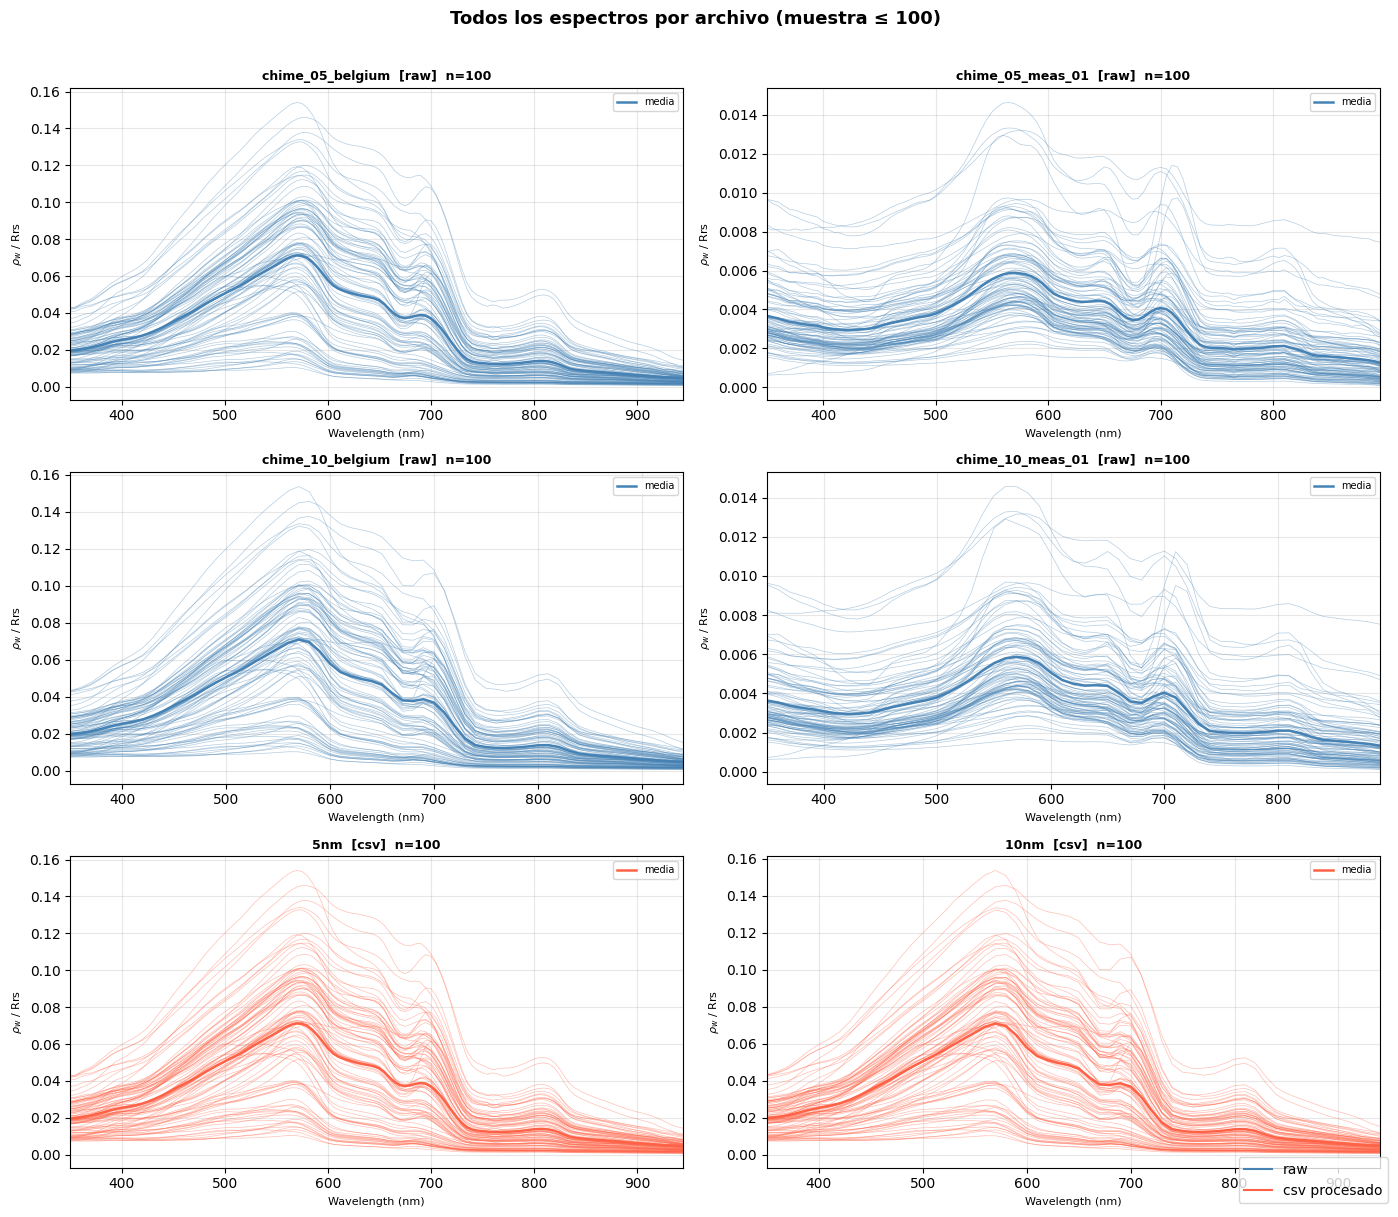


✓ Figura guardada como all_spectra_by_file.png


In [23]:
def plot_spectra_file(name, wl, rrs, kind, ax, color):
    """Dibuja hasta 100 espectros de un archivo en un eje dado."""
    if wl is None or rrs is None:
        ax.text(0.5, 0.5, f"{name}\n(sin datos)", ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='gray')
        ax.set_title(f"{name} [{kind}]", fontsize=9)
        return

    N = rrs.shape[0] if rrs.ndim > 1 else 1
    plot_idx = np.linspace(0, N - 1, min(N, 100), dtype=int)

    if rrs.ndim == 1:
        ax.plot(wl, rrs, lw=0.8, color=color)
    else:
        for i in plot_idx:
            ax.plot(wl, rrs[i, :], lw=0.5, alpha=0.4, color=color)
        # Media encima
        ax.plot(wl, np.nanmean(rrs, axis=0), lw=1.8, color=color,
                alpha=1.0, label='media')

    ax.set_xlabel('Wavelength (nm)', fontsize=8)
    ax.set_ylabel(r'$\rho_w$ / Rrs', fontsize=8)
    ax.set_title(f"{name}  [{kind}]  n={len(plot_idx)}", fontsize=9, fontweight='bold')
    ax.set_xlim(wl[0], wl[-1])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
    print(f"  {name:<30} Rrs range: {np.nanmin(rrs):.5f} – {np.nanmax(rrs):.5f}")


# ── Reúne todos los archivos (raw + csv) ──────────────────────────────────────
all_files = (
    [(k, "raw", spectra_raw[k]["wl"], spectra_raw[k]["rrs"]) for k in spectra_raw] +
    [(k, "csv", spectra_csv[k]["wl"], spectra_csv[k]["rrs"]) for k in spectra_csv]
)

n_files = len(all_files)
ncols   = 2
nrows   = int(np.ceil(n_files / ncols))

# Paleta: azul para raw, rojo para csv
palette = {"raw": "steelblue", "csv": "tomato"}

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharey=False)
axes = np.array(axes).flatten()

print("Rango de valores Rrs / ρw por archivo:")
for ax, (name, kind, wl, rrs) in zip(axes, all_files):
    plot_spectra_file(name, wl, rrs, kind, ax, color=palette[kind])

# Ocultar ejes sobrantes
for ax in axes[n_files:]:
    ax.set_visible(False)

# Leyenda global de colores
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', lw=1.5, label='raw'),
    Line2D([0], [0], color='tomato',    lw=1.5, label='csv procesado'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=10,
           bbox_to_anchor=(1.0, 0.01))

plt.suptitle('Todos los espectros por archivo (muestra ≤ 100)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_spectra_by_file.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Figura guardada como all_spectra_by_file.png')

---
## 9. Comparación numérica: estadísticas básicas (Rrs medio por banda)

In [21]:
for res, raw_key, csv_key in [("5nm", "chime_05_belgium", "5nm"),
                               ("10nm", "chime_10_belgium", "10nm")]:
    raw_spec = spectra_raw.get(raw_key, {})
    csv_spec = spectra_csv.get(csv_key, {})

    if raw_spec.get("wl") is None or csv_spec.get("wl") is None:
        print(f"[{res}] Datos incompletos, saltando...")
        continue

    # Interpolar al grid común para comparar
    wl_common = np.intersect1d(
        np.round(raw_spec["wl"], 1),
        np.round(csv_spec["wl"], 1)
    )

    if len(wl_common) == 0:
        print(f"[{res}] Sin longitudes de onda comunes, interpolando...")
        wl_common = np.union1d(raw_spec["wl"], csv_spec["wl"])
        mean_raw = np.interp(wl_common, raw_spec["wl"],
                             np.nanmean(raw_spec["rrs"], axis=0) if raw_spec["rrs"].ndim > 1 else raw_spec["rrs"])
        mean_csv = np.interp(wl_common, csv_spec["wl"],
                             np.nanmean(csv_spec["rrs"], axis=0) if csv_spec["rrs"].ndim > 1 else csv_spec["rrs"])
    else:
        raw_mean_all = np.nanmean(raw_spec["rrs"], axis=0) if raw_spec["rrs"].ndim > 1 else raw_spec["rrs"]
        csv_mean_all = np.nanmean(csv_spec["rrs"], axis=0) if csv_spec["rrs"].ndim > 1 else csv_spec["rrs"]
        raw_idx = [np.argmin(np.abs(raw_spec["wl"] - w)) for w in wl_common]
        csv_idx = [np.argmin(np.abs(csv_spec["wl"] - w)) for w in wl_common]
        mean_raw = raw_mean_all[raw_idx]
        mean_csv = csv_mean_all[csv_idx]

    diff = mean_raw - mean_csv
    rel_diff = (diff / (mean_csv + 1e-10)) * 100

    comp_df = pd.DataFrame({
        "λ (nm)"        : wl_common,
        "raw media"     : np.round(mean_raw, 6),
        "csv media"     : np.round(mean_csv, 6),
        "diff abs"      : np.round(diff, 6),
        "diff rel (%)"  : np.round(rel_diff, 2),
    })

    print(f"\n{'='*55}\n Resolución {res} — bandas comunes: {len(wl_common)}\n{'='*55}")
    display(comp_df.head(20))
    print(f"  RMSE: {np.sqrt(np.mean(diff**2)):.6f}")
    print(f"  MAE : {np.mean(np.abs(diff)):.6f}")
    print(f"  Diff relativa media: {np.mean(np.abs(rel_diff)):.2f}%")


 Resolución 5nm — bandas comunes: 120


,λ (nm),raw media,csv media,diff abs,diff rel (%)
0,350.0,0.019610,0.019610,0.0,0.0
1,355.0,0.019798,0.019798,0.0,0.0
2,360.0,0.020279,0.020279,0.0,0.0
3,365.0,0.020759,0.020759,0.0,0.0
4,370.0,0.021229,0.021229,0.0,0.0
5,375.0,0.021893,0.021893,0.0,0.0
6,380.0,0.022631,0.022631,0.0,0.0
7,385.0,0.023415,0.023415,0.0,0.0
8,390.0,0.024227,0.024227,0.0,0.0
9,395.0,0.024892,0.024892,0.0,0.0


  RMSE: 0.000000
  MAE : 0.000000
  Diff relativa media: 0.00%

 Resolución 10nm — bandas comunes: 60


,λ (nm),raw media,csv media,diff abs,diff rel (%)
0,350.0,0.019838,0.019838,0.0,0.0
1,360.0,0.020346,0.020346,0.0,0.0
2,370.0,0.021277,0.021277,0.0,0.0
3,380.0,0.022643,0.022643,0.0,0.0
4,390.0,0.024188,0.024188,0.0,0.0
5,400.0,0.025403,0.025403,0.0,0.0
6,410.0,0.026378,0.026378,0.0,0.0
7,420.0,0.027754,0.027754,0.0,0.0
8,430.0,0.029793,0.029793,0.0,0.0
9,440.0,0.032336,0.032336,0.0,0.0


  RMSE: 0.000000
  MAE : 0.000000
  Diff relativa media: 0.00%


---
## 10. Metadatos / columnas no espectrales en los CSVs

In [22]:
import re

for key, df in csv_data.items():
    numeric_named = [c for c in df.columns if re.match(r"^\d+\.?\d*$", str(c))]
    prefixed = [c for c in df.columns if re.match(r"(Rrs|rrs|wl|band)_?(\d+\.?\d*)", str(c))]
    spectral = set(numeric_named + prefixed)
    meta_cols = [c for c in df.columns if c not in spectral]

    print(f"\n[{key}] Columnas NO espectrales ({len(meta_cols)}):")
    for c in meta_cols:
        dtype = df[c].dtype
        sample = df[c].dropna().iloc[0] if not df[c].dropna().empty else "—"
        print(f"  {c:<30} dtype={str(dtype):<12} ejemplo: {sample}")


[5nm] Columnas NO espectrales (2):
  date                           dtype=datetime64[us] ejemplo: 1970-01-01 00:00:00
  icase                          dtype=int64        ejemplo: 0

[10nm] Columnas NO espectrales (2):
  date                           dtype=datetime64[us] ejemplo: 1970-01-01 00:00:00
  icase                          dtype=int64        ejemplo: 0
